In [1]:
from keras.datasets import imdb

In [10]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=5000)

<string>:6: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
/usr/local/lib/python3.6/dist-packages/tensorflow/python/keras/datasets/imdb.py:159: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  x_train, y_train = np.array(xs[:idx]), np.array(labels[:idx])
/usr/local/lib/python3.6/dist-packages/tensorflow/python/keras/datasets/imdb.py:160: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 

In [11]:
type(x_train)

numpy.ndarray

In [12]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape #각각문서개수 2만5천개

((25000,), (25000,), (25000,), (25000,))

In [13]:
max([x for r in x_train for x in r]) ##88586의 언어가 사용됨 - >너무많음 _바꿈 -> 넘버워즈

4999

In [19]:
len_list = ([len(r)for r in x_train]) # min = 11 max = 2494 11~2494

238.71364

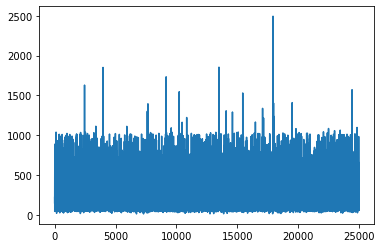

In [22]:
import numpy as np
import matplotlib.pyplot as plt
plt.plot(np.arange(len(len_list)), len_list) #1000정도 자르면됨
#평균 구하기
np.mean(len_list) #평균이 238 로 한 200에서 짤라줘도됨

In [23]:
from keras_preprocessing import sequence
x_train = sequence.pad_sequences(x_train, maxlen=100)
x_test = sequence.pad_sequences(x_test, maxlen=100)

In [24]:
y_train[0] #감성데이터라 0or 1 로(긍정부정) 구성돼 있어서 바꿀 필요없음-다중분류가아님

1

In [25]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation
from keras.layers import Embedding, LSTM
from keras.layers import Conv1D, MaxPool1D

In [27]:
model = Sequential()
model.add(Embedding(5000, 100))
model.add(Dropout(0.5))
model.add(Conv1D(64, 5, padding='valid', activation='relu', strides=1)) #64개의 데이터 커널사이즈 5, 패딩
model.add(MaxPool1D(pool_size=4)) # 4개중 하나씩 뽑음
model.add(LSTM(55))
model.add(Dense(1))
model.add(Activation('sigmoid'))
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_1 (Embedding)      (None, None, 100)         500000    
_________________________________________________________________
dropout_1 (Dropout)          (None, None, 100)         0         
_________________________________________________________________
conv1d_1 (Conv1D)            (None, None, 64)          32064     
_________________________________________________________________
max_pooling1d (MaxPooling1D) (None, None, 64)          0         
_________________________________________________________________
lstm (LSTM)                  (None, 55)                26400     
_________________________________________________________________
dense (Dense)                (None, 1)                 56        
_________________________________________________________________
activation (Activation)      (None, 1)                

In [28]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [29]:
model.fit(x_train, y_train, batch_size=100, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5
250/250 [==============================] - 12s 15ms/step - loss: 0.5737 - accuracy: 0.6525 - val_loss: 0.3344 - val_accuracy: 0.8534
Epoch 2/5
250/250 [==============================] - 3s 14ms/step - loss: 0.2824 - accuracy: 0.8828 - val_loss: 0.3282 - val_accuracy: 0.8557
Epoch 3/5
250/250 [==============================] - 3s 14ms/step - loss: 0.2380 - accuracy: 0.9053 - val_loss: 0.3317 - val_accuracy: 0.8545
Epoch 4/5
250/250 [==============================] - 3s 14ms/step - loss: 0.2087 - accuracy: 0.9208 - val_loss: 0.3325 - val_accuracy: 0.8556
Epoch 5/5
250/250 [==============================] - 3s 14ms/step - loss: 0.1713 - accuracy: 0.9364 - val_loss: 0.3660 - val_accuracy: 0.8512


In [30]:
model.evaluate(x_test, y_test)

782/782 [==============================] - 3s 3ms/step - loss: 0.3660 - accuracy: 0.8512


[0.3660373389720917, 0.8511599898338318]